This notebook applies the Conveyal Estimated LTS framework (Conveyal 2015; Mekuria et al. 2012), augmented by Jeong & Smith (2025), to the **Belfast** road network.

**Purpose:** produce a Belfast-specific LTS network with full topological connectivity for downstream connectivity analysis, routing, and accessibility modelling.

## Methodology Overview

1. **OSM network extraction** — download the full road network via OSMnx, preserving node-edge topology (`u`/`v` node IDs) for graph connectivity
2. **Cycle infrastructure classification** — derive 6 categories (Protected a/b/c, Unprotected Mandatory, Unprotected Advisory, Off-Road) from OSM tags following Jeong & Smith (2025) Table 1
3. **Level of Traffic Stress (LTS)** — augmented Conveyal-based scheme with Routino fallback, cycle infrastructure override, and signalised junction adjustment

## References

- Jeong, P. & Smith, D. (2025). *Improving Infrastructure and Accessibility Indicators for Urban Cycling Networks.* CASA Working Paper 242.
- Mekuria, M. C., Furth, P. G., & Nixon, H. (2012). *Low-Stress Bicycling and Network Connectivity.* MTI Report 11-19.
- Conveyal (2015). *Cycling Level of Traffic Stress.*
- Department for Transport (2020). *LTN 1/20: Cycle Infrastructure Design.*

## Environment setup

In [2]:
import warnings
warnings.filterwarnings('ignore')

import os
import json
from pathlib import Path

import re
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point, LineString, Polygon

# Network analysis
import networkx as nx
import igraph as ig

# OSM
import osmnx as ox
ox.settings.use_cache = True
ox.settings.log_console = False

import folium

from collections import defaultdict

# Project paths
DATA_DIR = Path('../Data')
OUTPUT_DIR = Path('../Figure')
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

# Coordinate reference systems
CRS_WGS84 = 'EPSG:4326'    # OSM native
CRS_IG    = 'EPSG:29903'   # Irish Grid

print('Environment ready.')
print(f"Working directory: {os.getcwd()}")


Environment ready.
Working directory: G:\我的云端硬盘\PCTNI\Code


## Study area — Belfast LGD

Filter the NI Super Data Zones (SDZ) to Belfast Local Government District.
All spatial operations use Irish Grid (EPSG:29903).

In [3]:
# Load NI Super Data Zones and filter to Belfast LGD
raw_data = gpd.read_file(DATA_DIR / 'zones_sdz.gpkg', engine='pyogrio')
raw_data = raw_data.to_crs(CRS_IG)

# Identify Belfast — check exact LGD name
print('Available LGDs:', sorted(raw_data['lgd2014_nm'].unique()))

# Filter to Belfast
belfast_zones = raw_data[raw_data['lgd2014_nm'] == 'Belfast'].copy()

# Create a dissolved union for spatial operations
belfast_boundary = belfast_zones.unary_union

print(f'Belfast SDZ zones: {len(belfast_zones)}')
print(f'Belfast area: {belfast_zones.geometry.area.sum() / 1e6:.1f} km²')


Available LGDs: ['Antrim and Newtownabbey', 'Ards and North Down', 'Armagh City, Banbridge and Craigavon', 'Belfast', 'Causeway Coast and Glens', 'Derry City and Strabane', 'Fermanagh and Omagh', 'Lisburn and Castlereagh', 'Mid Ulster', 'Mid and East Antrim', 'Newry, Mourne and Down']
Belfast SDZ zones: 175
Belfast area: 137.7 km²


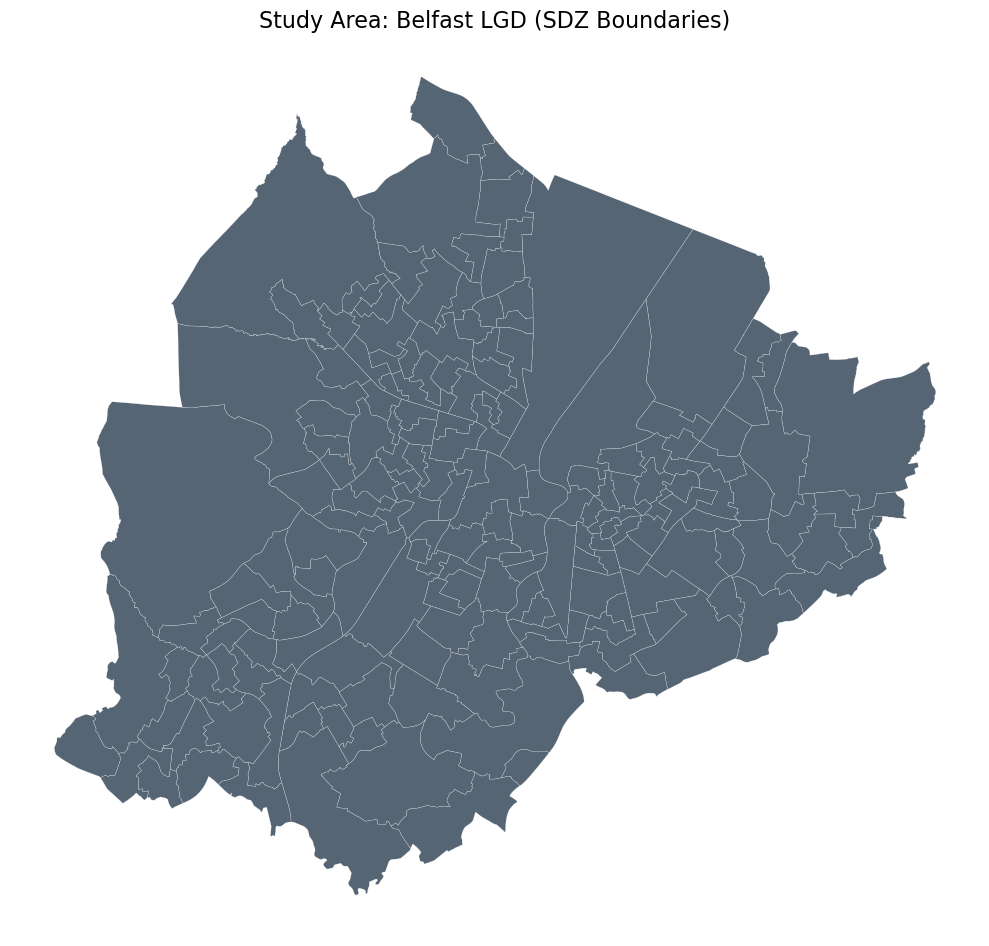

In [4]:
fig, ax = plt.subplots(figsize=(10, 10))
belfast_zones.plot(ax=ax, edgecolor='white', linewidth=0.2,
                   facecolor='#2c3e50', alpha=0.8)
ax.set_title('Study Area: Belfast LGD (SDZ Boundaries)', fontsize=16)
ax.set_axis_off()
plt.tight_layout()
plt.show()


## Extract the OSM road network

The road network is extracted via **OSMnx** using the Belfast LGD boundary
polygon. OSMnx preserves the full node-edge topology of the OSM graph,
assigning unique node IDs (`u`, `v`) to each edge — this ensures the
resulting network is topologically connected and directly routable.

`network_type='all'` is used because Northern Ireland has very few edges
with dedicated cycling tags — using `'cycling'` returns near-zero results.
Key cycling-relevant OSM tags (`cycleway`, `cycleway:left/right/both`,
`bicycle`, `surface`, `segregated`, `lit`) are requested via
`ox.settings.useful_tags_way` to ensure the infrastructure classification
and LTS pipeline have complete attribute coverage.

After extraction, edges are reprojected to **Irish Grid (EPSG:29903)** and
saved as GeoParquet with `u`, `v`, `key` columns preserved.

In [6]:
# ── Study area setup ────────────────────────────────────────────────────────
study_area = belfast_zones.copy()
belfast_poly_4326 = study_area.to_crs(CRS_WGS84).unary_union

# ── Configure OSMnx to pull cycling-relevant tags ────────────────────────────
ox.settings.useful_tags_way += [
    'cycleway', 'cycleway:left', 'cycleway:right', 'cycleway:both',
    'bicycle', 'foot', 'segregated', 'lit', 'surface', 'smoothness',
    'busway', 'motor_vehicle', 'motorcar', 'psv', 'tracktype',
]
# Deduplicate
ox.settings.useful_tags_way = list(set(ox.settings.useful_tags_way))

# ── Extract network ─────────────────────────────────────────────────────────
G_osm = ox.graph_from_polygon(
    belfast_poly_4326,
    network_type='bike',
    simplify=True,
    retain_all=False,
)

print(f'OSMnx graph — nodes: {G_osm.number_of_nodes():,}, edges: {G_osm.number_of_edges():,}')
print(f'Connected: {nx.is_connected(G_osm.to_undirected())}')


OSMnx graph — nodes: 29,523, edges: 68,927
Connected: True


In [7]:
# ── Convert to GeoDataFrames ────────────────────────────────────────────────
nodes_ox, edges = ox.graph_to_gdfs(G_osm)
edges = edges.reset_index()  # u, v, key become regular columns
edges = edges.to_crs(CRS_IG)
edges['length'] = edges.geometry.length  # recalculate in projected CRS

print(f'Edges: {len(edges):,}')
print(f'Columns include u/v: {"u" in edges.columns and "v" in edges.columns}')

pd.set_option('display.max_columns', None)
edges.head()


Edges: 68,927
Columns include u/v: True


,u,v,key,osmid,ref,maxspeed,surface,junction,lanes,name,highway,oneway,reversed,length,geometry,cycleway:both,cycleway,smoothness,lit,bicycle,bridge,cycleway:left,foot,busway,cycleway:right,access,motor_vehicle,psv,service,segregated,width,tunnel,tracktype,motorcar
0,351532,282111371,0,"[881853802, 881853803, 1119886637]",C703,30 mph,asphalt,"[roundabout, circular]","[3, 4]",Broadway Roundabout,tertiary,True,False,42.556834,"LINESTRING (332023.894 373024.406, 332016.77 3...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,351599,11812501402,0,38485621,NaN,NaN,asphalt,NaN,NaN,Boyne Court,residential,False,True,37.889709,"LINESTRING (333408.482 373411.502, 333373.173 ...",no,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,351599,351600,0,5209408,B503,30 mph,asphalt,NaN,2,Sandy Row,secondary,False,False,69.120001,"LINESTRING (333408.482 373411.502, 333415.107 ...",NaN,no,intermediate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,351599,1121792828,0,5209408,B503,30 mph,asphalt,NaN,2,Sandy Row,secondary,False,True,59.556372,"LINESTRING (333408.482 373411.502, 333403.845 ...",NaN,no,intermediate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,351600,231772694,0,5209408,B503,30 mph,asphalt,NaN,2,Sandy Row,secondary,False,False,13.857428,"LINESTRING (333424.119 373478.83, 333426.772 3...",NaN,no,intermediate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


> To save time, the edges can be saved/loaded as parquet. Skip the cells above and read directly:
>
> ```python
> edges = gpd.read_parquet(DATA_DIR / 'cycling_network_osmnx.parquet')
> ```

In [8]:
# ── Flatten list-type columns before saving ─────────────────────────────────
list_cols = ['lanes', 'maxspeed', 'name', 'ref', 'bridge', 'tunnel', 
             'width', 'surface', 'access', 'service', 'junction']

for col in edges.columns:
    if edges[col].apply(lambda x: isinstance(x, list)).any():
        edges[col] = edges[col].apply(lambda x: x[0] if isinstance(x, list) else x)
        
edges.to_parquet(DATA_DIR / 'cycling_network_osmnx.parquet')
nodes_ox.to_parquet(DATA_DIR / 'cycling_nodes_osmnx.parquet')
print(f'Saved edges and nodes to {DATA_DIR}')


Saved edges and nodes to ..\Data


## Cycle infrastructure classification

Before categorising cycle infrastructure, the road network dataset was checked to exclude highway types that are mis-specified, misspelled in OSM, or unsuitable for cycling. Their exclusion criteria cover motorways and motorway links (legally prohibited for cycling), busways without explicit bicycle access, segments tagged as under construction or proposed, and common OSM misspellings such as cycleway way. 

> Although there are no motorways in this dataframe (because the `network_type='cycling'` was used when extract the cycling network.), and no misspelled rows.

An inspection of the Belfast OSM data revealed additional invalid or non-cyclable highway values (steps), which were also removed.

In [9]:
# OSMnx highway column can be a list — flatten to first value
edges['highway'] = edges['highway'].apply(lambda x: x[0] if isinstance(x, list) else x)
print(edges['highway'].value_counts().to_string())


highway
residential       26413
service           20991
path               6851
tertiary           4121
primary            2328
unclassified       2052
secondary          1735
cycleway           1374
trunk               880
living_street       777
track               627
pedestrian          490
trunk_link           91
tertiary_link        69
primary_link         63
secondary_link       51
busway               14


In [10]:
def filter_unsuitable_highways(edges):
    """
    Pre-process road network to exclude highway types that are
    unsuitable for cycling or legally prohibited.

    Based on Jeong & Smith (2025), adapted for the study area data.

    Excluded categories:
    - Motorways and motorway links (legally prohibited for cycling)
    - Pedestrian-only infrastructure (steps, corridor)
    - Construction / proposed / planned (not yet built)
    - Common OSM misspellings and invalid tags
    
    Returns: filtered GeoDataFrame
    """
    # Define highway types to be strictly excluded
    exclude_exact = {
        'motorway', 'motorway_link',  # Legally prohibited
        'steps',                      # Physical barrier
        'corridor',                   # Usually indoor/invalid for routing
        'proposed', 'construction',   # Non-existent infrastructure
        'abandoned', 'platform',      # Non-road features
        'raceway', 'emergency_bay',   # Invalid/Safety risk
        'no', 'services'              # Mis-tags or non-cyclable areas
    }

    # Normalize highway tags to lowercase and strip whitespace for robust matching
    highway = edges['highway'].astype(str).str.strip().str.lower()

    # Create a mask for rows to exclude
    mask_exclude = highway.isin(exclude_exact)

    # Record the count before filtering
    n_before = len(edges)
    
    # Apply the filter (keeping rows that are NOT in the exclusion list)
    edges_filtered = edges[~mask_exclude].copy()
    
    # Record the count after filtering
    n_after = len(edges_filtered)

    print(f"Highway filtering: {n_before} -> {n_after} edges "
          f"({n_before - n_after} removed)")

    # Print summary of removed types if any were found
    if mask_exclude.any():
        print("\nRemoved highway types:")
        print(edges.loc[mask_exclude, 'highway'].value_counts().to_string())

    return edges_filtered
    

### Cycle infrastructure classification

Each road segment is classified into one of six cycle infrastructure categories based on [OSM tags](https://wiki.openstreetmap.org/wiki/Key:highway#When_cycleway_is_drawn_as_its_own_way_(see_Bicycle)):

| Category | OSM mapping |
|---|---|
| Protected Cycle Lane (a) — adjacent to road | `cycleway=track`, `cycleway:right=track`, `cycleway:left=track` |
| Protected Cycle Lane (b) — designated cycleway | `highway=cycleway` (excluding shared bus lanes) |
| Protected Cycle Lane (c) — separated cycleway | `cycleway=separate`, `cycleway=sidepath`, `bicycle=use_sidepath` |
| Unprotected Mandatory Cycle Lane | `cycleway=lane` and lane-related tags (excluding shared bus) |
| Unprotected Advisory Cycle Lane | `cycleway=advisory`, `cycleway=shared`, `cycleway=share_busway` |
| Off-Road Path | `highway=path/track/footway` + `bicycle=designated/yes` |
| (Default) Road without cycle infrastructure | Anything not matching above |

In [11]:
def classify_cycle_infrastructure(row):
    """
    Classify a road segment into one of 6 cycle infrastructure categories
    plus a default 'no infrastructure' class.

    Following Jeong & Smith (2025) Table 1.

    Returns: str — one of {'protected_a', 'protected_b', 'protected_c',
                            'unprotected_mandatory', 'unprotected_advisory',
                            'off_road', 'none'}
    """
    highway = str(row.get('highway', '') or '')
    cycleway = str(row.get('cycleway', '') or '')
    cycleway_left = str(row.get('cycleway:left', '') or '')
    cycleway_right = str(row.get('cycleway:right', '') or '')
    cycleway_both = str(row.get('cycleway:both', '') or '')
    bicycle = str(row.get('bicycle', '') or '')

    # Protected (b): dedicated cycleway as separate geometry
    if highway == 'cycleway':
        # Exclude shared bus lanes/ways
        if cycleway not in ('share_busway', 'shared_busway'):
            return 'protected_b'

    # Protected (c): cycleway physically separated from road
    if cycleway in ('separate', 'sidepath') or bicycle == 'use_sidepath':
        return 'protected_c'

    # Protected (a): track adjacent to road
    track_tags = ('track',)
    if (cycleway in track_tags
        or cycleway_left in track_tags
        or cycleway_right in track_tags
        or cycleway_both in track_tags):
        return 'protected_a'

    # Unprotected mandatory cycle lane
    lane_tags = ('lane', 'opposite_lane')
    if (cycleway in lane_tags
        or cycleway_left in lane_tags
        or cycleway_right in lane_tags
        or cycleway_both in lane_tags):
        return 'unprotected_mandatory'

    # Unprotected advisory (includes shared bus lanes)
    advisory_tags = ('advisory', 'shared', 'share_busway', 'shared_lane', 'shared_busway')
    if (cycleway in advisory_tags
        or cycleway_left in advisory_tags
        or cycleway_right in advisory_tags
        or cycleway_both in advisory_tags):
        return 'unprotected_advisory'

    # Off-road paths with bicycle access
    if highway in ('path', 'track', 'footway'):
        if bicycle in ('designated', 'yes'):
            return 'off_road'

    return 'none'


In [12]:
if edges is not None:
    # Step 1: Remove mis-specified / non-cyclable highway types
    edges = filter_unsuitable_highways(edges)

    # Step 2: Classify cycle infrastructure
    edges['cycle_infra'] = edges.apply(classify_cycle_infrastructure, axis=1)

    # Distribution check
    print("\nCycle infrastructure distribution (by edge count):")
    print(edges['cycle_infra'].value_counts())
    print(f"\n% with any cycle infrastructure: "
          f"{(edges['cycle_infra'] != 'none').mean() * 100:.1f}%")


Highway filtering: 68927 -> 68927 edges (0 removed)

Cycle infrastructure distribution (by edge count):
cycle_infra
none                     64971
protected_b               1374
unprotected_mandatory     1154
unprotected_advisory       994
off_road                   389
protected_a                 40
protected_c                  5
Name: count, dtype: int64

% with any cycle infrastructure: 5.7%


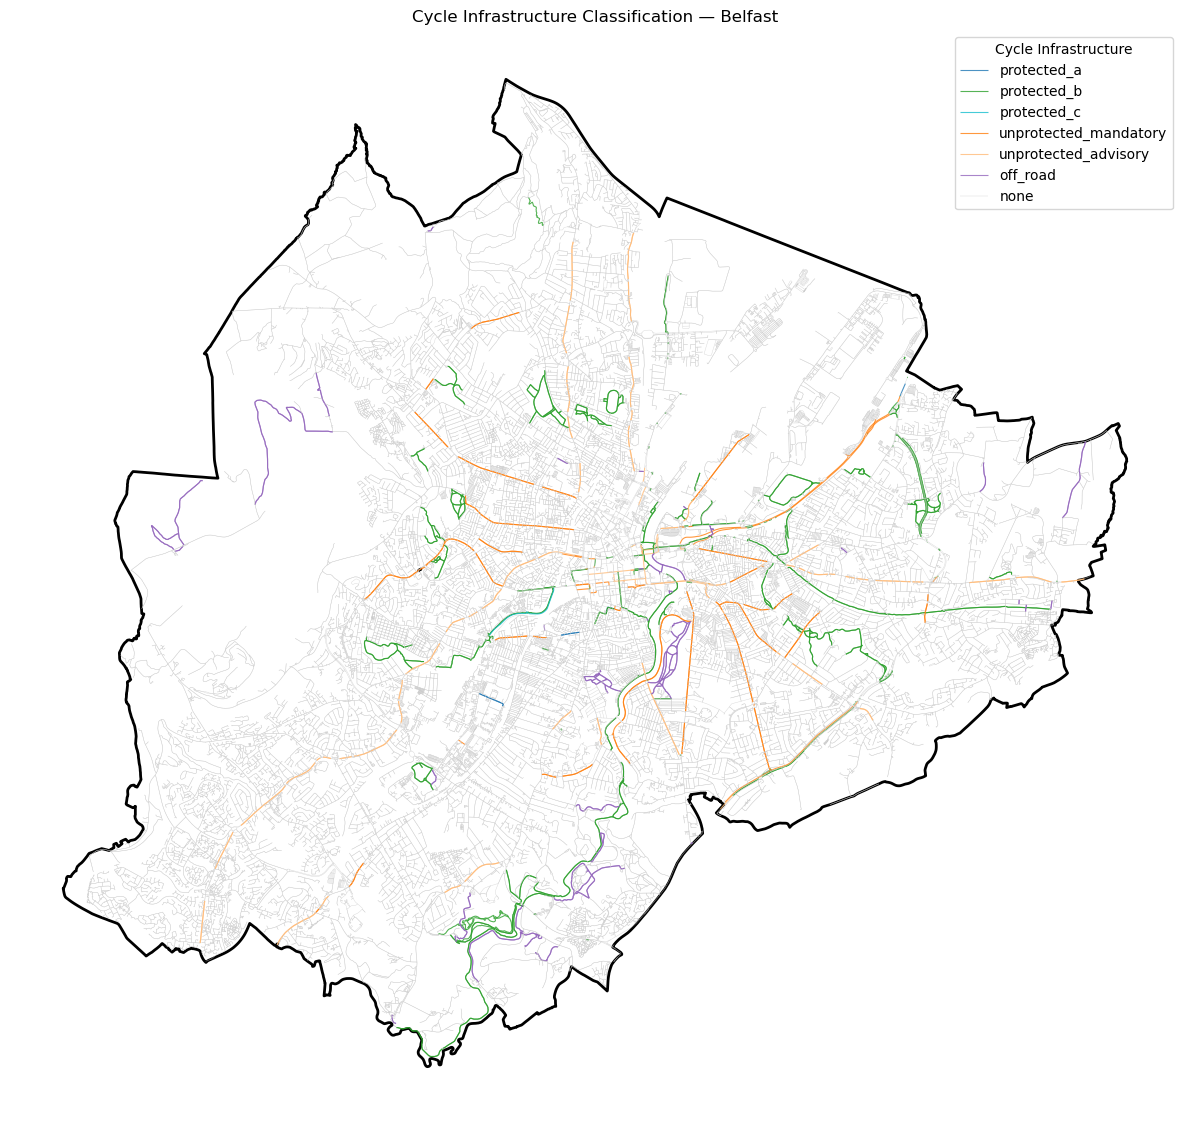

In [13]:
# Sanity check: visualise a small area
if edges is not None:
    bbox_bng = edges.total_bounds  
    cc_edges = edges.cx[bbox_bng[0]:bbox_bng[2], bbox_bng[1]:bbox_bng[3]]

    colour_map = {
        'protected_a': '#1f77b4',
        'protected_b': '#2ca02c',
        'protected_c': '#17becf',
        'unprotected_mandatory': '#ff7f0e',
        'unprotected_advisory': '#ffbb78',
        'off_road': '#9467bd',
        'none': '#cccccc',
    }

    fig, ax = plt.subplots(figsize=(12, 12))
    for cat, colour in colour_map.items():
        subset = cc_edges[cc_edges['cycle_infra'] == cat]
        if not subset.empty:
            subset.plot(ax=ax, color=colour, linewidth=0.8 if cat != 'none' else 0.3,
                       label=cat, alpha=0.8)
    gpd.GeoDataFrame(geometry=[belfast_boundary], crs=study_area.crs).to_crs(edges.crs).plot(
        ax=ax, facecolor='none', edgecolor='black',
        linewidth=2, linestyle='-', alpha=1, zorder=0)
    ax.legend(title='Cycle Infrastructure', loc='upper right')
    ax.set_title('Cycle Infrastructure Classification — Belfast')
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()


## Level of Traffic Stress
The [Conveyal Estimated LTS scheme](https://docs.conveyal.com/learn-more/traffic-stress) (Conveyal 2015) is a sequential rule-based implementation of the Mekuria et al. (2012) methodology, adapted for contexts where only standard OpenStreetMap tags are available. It prioritises physical road attributes and applies conservative inference rules where data is incomplete, trading some precision for broad network coverage.

**Core Principles:**

1. **Physical Parameter Dependency**: LTS values are derived from the interaction between posted speed limits, lane counts, and the presence of cycling infrastructure tags. These three variables form the primary decision matrix for all non-residential roads.

2. **Conservative Inference for Missing Data**: Where critical tags such as `maxspeed` or `lanes` are absent, the model applies road-class-specific defaults rather than leaving segments unassigned. For example, tertiary roads with unknown speed and fewer than four lanes default to LTS 2, reflecting the assumption that minor roads are unlikely to be high-speed. Only `highway=service` segments are deliberately left unclassified, to prevent stress levels from service lanes bleeding into adjacent streets.

3. **Unsignalised Intersection Adjustment**: After per-edge classification, a second pass propagates stress levels at junctions. At each vertex without a traffic signal tag, the maximum LTS of all incident edges is assigned to every connecting edge. This reflects the crossing difficulty experienced at uncontrolled intersections on otherwise low-stress routes. Signalised intersections are treated as neutral and excluded from this adjustment.

**Classification Procedure:**

The scheme operates as a sequential decision tree applied to each edge independently, followed by a network-level intersection adjustment.

**Table a — [Conveyal LTS Base Classification Sequent Rules (from Conveyal Github Repo)](https://github.com/conveyal/analysis-backend/blob/v5.9.0/src/main/java/com/conveyal/r5/labeling/LevelOfTrafficStressLabeler.java) (Initial Round)**

| Priority | Condition | LTS Assigned |
|----------|-----------|--------------|
| 1 | Explicit `lts` tag present in source data | Value of tag (1–4) |
| 2 | Motor vehicles prohibited (no `ALLOWS_CAR` flag) | 1 |
| 3 | `highway = service` | Unclassified (intentional) |
| 4 | `highway = residential` or `living_street` | 1 |
| 5 | `maxspeed ≤ 25 mph` AND lanes ≤ 3 or unknown | Default = LTS 2 |
| 6 | `highway = tertiary` / `unclassified` / `tertiary_link`, lanes ≤ 3, speed unknown | Default = LTS 2 |
| 7 | Above road classes + cycling infrastructure present | 2 |
| 8 | Other roads (`primary`, `secondary`, `trunk`) + cycling infrastructure | Default LTS (2 or 3) |
| 9 | No condition matched | 4 |

*Note: "cycling infrastructure present" refers to `cycleway=lane`, `cycleway:left/right=lane`, or equivalent directional tags. Default LTS in rows 5–8 is 2 if the road is slow (≤ 25 mph) with few or unknown lanes, otherwise 3.*

**Table b — Speed × Lane Count Decision Matrix (Non-Residential, Non-Tertiary Roads)**

| | Lanes ≤ 3 | Lanes ≥ 4 | Lanes unknown |
|---|---|---|---|
| Speed ≤ 25 mph | Default LTS **2** | Default LTS **3** | Default LTS **2** |
| Speed > 25 mph | Default LTS **3** | Default LTS **3** | Default LTS **3** |
| Speed unknown | Default LTS **3** | Default LTS **3** | Default LTS **3** |

*This default is then overridden upward or downward by the presence of cycling infrastructure and road class (see Table 4.1).*

**Table c — Unsignalised Intersection Adjustment**

| Vertex condition | Action |
|---|---|
| Has `traffic_signal` tag | No adjustment; vertex excluded |
| No signal tag | All incident edges reassigned to max LTS among all incident edges |

*This step may produce counterintuitive results: a dedicated cycleway (LTS 1) crossing an LTS 4 arterial will be relabelled LTS 4 on both approach segments, even though the path itself provides physical separation. This is a known limitation of the original Conveyal scheme.*

**Limitations:**

The original scheme has two notable constraints relevant to this study. First, the directional assignment of cycling infrastructure (distinguishing `cycleway:right=lane` from `cycleway:left=lane`) is simplified in Python implementations that process undirected edges, potentially misassigning LTS on one-way streets or contraflow lanes. Second, the intersection adjustment can substantially reduce the apparent extent of low-stress networks in dense urban areas, where low-stress paths frequently cross arterials, as documented by Mekuria et al. (2012) and discussed further in Section 4.3.

### Step 1: Speed Parser
Parses the OSM `maxspeed` tag into a standardised km/h value. Handles multiple unit formats (mph, knots, km/h) and returns `NaN` for missing or unparseable values. The 25 mph (~40.23 km/h) threshold used later to distinguish "slow" vs "fast" roads originates from the Conveyal LTS methodology.

In [14]:
SPEED_THRESHOLD_KMH = 25 * 1.609  # 25 mph -> ~40.23 km/h

def get_speed_kmh(maxspeed_tag) -> float:
    if pd.isna(maxspeed_tag) or str(maxspeed_tag).strip() == '':
        return np.nan
    s = str(maxspeed_tag).lower().strip()
    # OSMnx may return lists — take first value
    if s.startswith('['):
        try:
            s = eval(s)[0]
            s = str(s).lower().strip()
        except:
            return np.nan
    m = re.match(r'^([0-9][\.0-9]*?) ?(km/h|kmh|kph|mph|knots)?$', s)
    if not m:
        return np.nan
    val, unit = float(m.group(1)), m.group(2)
    if unit == 'mph':    return val * 1.609
    if unit == 'knots':  return val * 1.852
    return val


### Step 2: Conveyal Per-Edge LTS Classification
The core classification function. Assigns an LTS level (1–4) to each cyclable edge based on highway type, speed, lane count, and cycling infrastructure. The logic follows the Conveyal/Mekuria approach: dedicated cycling facilities and quiet residential streets get LTS 1; roads with unknown or moderate conditions default to LTS 2–3; high-speed multi-lane roads without protection get LTS 4. `service` roads return `None` (deferred to the fallback step).

In [15]:
NO_CAR_HIGHWAYS = {
    'cycleway', 'path', 'footway', 'pedestrian', 'track', 'bridleway'
}

def calculate_lts(row) -> int | None:
    highway     = str(row.get('highway',     '') or '').lower().strip()
    cycle_infra = str(row.get('cycle_infra', 'none') or 'none').lower().strip()

    if highway in NO_CAR_HIGHWAYS:                  return 1
    if highway == 'service':                        return None
    if highway in ('residential', 'living_street'): return 1

    speed_kmh = get_speed_kmh(row.get('maxspeed'))
    try:
        lanes_val = row.get('lanes')
        if isinstance(lanes_val, list):
            lanes_val = lanes_val[0]
        lanes = int(float(lanes_val)) if pd.notnull(lanes_val) else MISSING_LANES
    except (ValueError, TypeError):
        lanes = MISSING_LANES

    slow_road     = (not np.isnan(speed_kmh)) and (speed_kmh <= SPEED_THRESHOLD_KMH)
    unknown_speed = np.isnan(speed_kmh)
    few_lanes     = lanes <= LANE_THRESHOLD
    unknown_lanes = lanes == MISSING_LANES

    default_lts = 3
    if slow_road and (few_lanes or unknown_lanes):  default_lts = 2
    elif few_lanes and unknown_speed:               default_lts = 2

    if highway in ('unclassified', 'tertiary', 'tertiary_link'):
        if unknown_lanes and slow_road:   default_lts = 2
        if cycle_infra in ('protected_a', 'unprotected_mandatory', 'unprotected_advisory'):
            return 2
        return default_lts

    if cycle_infra in ('protected_a', 'unprotected_mandatory', 'unprotected_advisory'):
        return default_lts

    return 4


### Step 3: Cyclability Filter
Determines whether an edge is legally and practically cyclable. Excludes motorways, construction/proposed roads, private driveways/parking aisles, and edges explicitly tagged `bicycle=no`. This filter is applied before LTS classification so that non-cyclable edges are never assigned an LTS value.

In [16]:
def is_cyclable(row) -> bool:
    highway = str(row.get('highway', '') or '').lower().strip()
    if highway in {'motorway', 'motorway_link', 'proposed', 'construction',
                   'abandoned', 'platform'}:
        return False
    service_type = str(row.get('service', '') or '').lower().strip()
    if highway == 'service' and service_type in {
        'parking_aisle', 'driveway', 'drive-through', 'car_wash', 'garages'
    }:
        return False
    bicycle = row.get('bicycle', '')
    if isinstance(bicycle, list):
        bicycle = bicycle[0]
    if str(bicycle or '').lower().strip() in ('no', 'private', 'restricted'):
        return False
    return True


### Step 4: Cycle Infrastructure Override
Post-classification override based on the quality of cycling infrastructure. Edges with fully separated facilities (`protected_b`, `protected_c`, `off_road` — corresponding to physically kerbed tracks, completely grade-separated paths, or off-road routes) are downgraded to LTS 1 regardless of the road they run alongside. Adjacent cycle tracks (`protected_a` — on-road but with physical separation) are set to LTS 2. This reflects the LTN 1/20 principle that high-quality infrastructure can make even busy roads comfortable for cycling.

In [17]:
def apply_cycle_infra_override(edges: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    ci = edges['cycle_infra'].str.lower().str.strip()
    fully_protected = ci.isin(['protected_b', 'protected_c', 'off_road'])
    adjacent_track  = ci == 'protected_a'
    edges.loc[fully_protected, 'lts'] = 1
    edges.loc[adjacent_track,  'lts'] = 2
    print(f"  protected_b/c/off_road -> LTS 1 : {fully_protected.sum():,} edges")
    print(f"  protected_a            -> LTS 2 : {adjacent_track.sum():,} edges")
    return edges


### Step 5: Routino Highway Fallback
Catches any edges that still have no LTS value after Steps 2–4 (typically `service` roads or uncommon highway types). Assigns a conservative LTS based purely on highway classification using a lookup dictionary derived from the Routino routing engine's assumptions. For example, `steps` → LTS 3, `trunk` → LTS 4. This ensures no cyclable edge is left unclassified.

In [18]:
ROUTINO_FALLBACK_LTS: dict[str, int] = {
    'cycleway': 1, 'path': 1, 'track': 1, 'living_street': 1,
    'footway': 1, 'pedestrian': 1,
    'service': 2, 'bridleway': 2,
    'steps': 3, 'secondary': 3,
    'primary': 4, 'primary_link': 4, 'trunk': 4, 'trunk_link': 4,
}

def apply_routino_fallback(edges: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    mask = edges['lts'].isna()
    if mask.sum() == 0:
        print("  No unclassified edges.")
        return edges
    fallback = edges.loc[mask, 'highway'].str.lower().str.strip().map(ROUTINO_FALLBACK_LTS)
    edges.loc[mask, 'lts'] = fallback
    print(f"  Filled : {fallback.notna().sum():,}  |  Still NaN : {edges['lts'].isna().sum():,}")
    return edges


### Step 6: Jeong & Smith Signalised Intersection Adjustment

A more nuanced intersection treatment is adopted which distinguishes between signalised and unsignalised junctions using OSM `highway=traffic_signals` nodes. At signalised intersections, if all converging edges are already LTS ≤ 2, the junction stress is reduced to LTS 1 (signals provide protected crossing). If there's a mix of low and high-stress edges, the junction LTS is reduced by one level (e.g. max LTS 3 → junction LTS 2), reflecting the partial protection that signals offer. Unsignalised intersections follow the same max-propagation rule. This produces a less pessimistic network than Conveyal's blanket approach and better reflects real-world cycling comfort at controlled crossings.

#### Extract traffic signals

Traffic signal nodes are extracted from OSMnx (which stores them as node
attributes) rather than from a separate PBF file. This keeps the pipeline
self-contained within the OSMnx-extracted graph.

In [19]:
# ── Extract traffic signals from OSMnx node attributes ─────────────────────
# OSMnx stores highway tags on nodes — filter for traffic_signals
traffic_signals = nodes_ox[nodes_ox['highway'] == 'traffic_signals'].copy()
traffic_signals = traffic_signals.to_crs(CRS_IG)

if len(traffic_signals) == 0:
    # Fallback: query OSM directly for traffic signals in the area
    print('No traffic signals found in node attributes, querying OSM...')
    ts_tags = {'highway': 'traffic_signals'}
    traffic_signals = ox.features_from_polygon(belfast_poly_4326, tags=ts_tags)
    traffic_signals = traffic_signals[traffic_signals.geometry.type == 'Point'].copy()
    traffic_signals = traffic_signals.to_crs(CRS_IG)

print(f'Traffic signal nodes: {len(traffic_signals):,}')


Traffic signal nodes: 12


### Shared Helper: Endpoint Extraction & Vertex-Edge Map

With the OSMnx-extracted network, the vertex-edge map is built directly from
the `u` and `v` node ID columns rather than from geometry coordinates. This
ensures topological correctness — no coordinate-rounding ambiguity.

In [20]:
def _build_vertex_edge_map_from_uv(edges):
    """
    Build vertex → edge index map using u/v node IDs.
    Only returns vertices with 3+ edges (intersections).
    """
    ve = defaultdict(list)
    for idx, row in edges.iterrows():
        ve[row['u']].append(idx)
        ve[row['v']].append(idx)
    return {node: eidxs for node, eidxs in ve.items() if len(eidxs) >= 3}


def apply_jeong_smith_intersection(
    edges: gpd.GeoDataFrame,
    traffic_signals: gpd.GeoDataFrame,
    nodes: gpd.GeoDataFrame,
    signal_buffer_m: float = 15.0,
) -> gpd.GeoDataFrame:
    """
    Signalised intersection adjustment using u/v node IDs.
    """
    intersections = _build_vertex_edge_map_from_uv(edges)
    sig_geoms = traffic_signals.geometry.values
    sig_sindex = traffic_signals.sindex

    # Get node coordinates for signal proximity check
    nodes_ig = nodes.to_crs(CRS_IG)

    def is_signalised(node_id):
        if node_id not in nodes_ig.index:
            return False
        pt = nodes_ig.loc[node_id, 'geometry']
        cands = list(sig_sindex.intersection(pt.buffer(signal_buffer_m).bounds))
        return any(sig_geoms[i].distance(pt) <= signal_buffer_m for i in cands)

    edges = edges.copy()
    lts_series = edges['lts'].copy()
    n_unsig = n_sig = n_reduced = 0

    for node_id, edge_idxs in intersections.items():
        vals = [lts_series[i] for i in edge_idxs if pd.notnull(lts_series[i])]
        if not vals:
            continue
        mx = max(vals)

        if is_signalised(node_id):
            n_sig += 1
            mn = min(vals)
            if mx <= 2:                    jlts = 1;      n_reduced += 1
            elif mn <= 2 and mx >= 3:      jlts = mx - 1; n_reduced += 1
            else:                          jlts = mx
        else:
            n_unsig += 1
            jlts = mx

        for i in edge_idxs:
            if pd.notnull(lts_series[i]) and jlts > lts_series[i]:
                lts_series[i] = jlts

    edges['lts'] = lts_series
    print(f"  Intersections : {len(intersections):,}")
    print(f"  Unsignalised  : {n_unsig:,}  |  Signalised : {n_sig:,}  |  Reduced : {n_reduced:,}")
    return edges


### Execute Pipeline
Runs the full LTS classification pipeline sequentially. First filters edges to only cyclable segments (Step 3), then applies the base per-edge LTS classification (Step 2), overrides with cycle infrastructure quality (Step 4), fills remaining gaps via highway-type fallback (Step 5), and finally applies the signalised intersection adjustment (Step 6).

In [21]:
SPEED_THRESHOLD_KMH = 25 * 1.609   # 25 mph -> ~40.23 km/h
LANE_THRESHOLD      = 3
MISSING_LANES       = 999

if edges is not None:

    # Step 3 → Filter to cyclable edges only
    edges['lts'] = np.nan
    cyclable_mask = edges.apply(is_cyclable, axis=1)

    # Step 2 → Base per-edge LTS classification (calls Step 1 internally)
    edges.loc[cyclable_mask, 'lts'] = edges[cyclable_mask].apply(calculate_lts, axis=1)

    # Step 4 → Cycle infrastructure override
    edges = apply_cycle_infra_override(edges)

    # Step 5 → Routino highway fallback for remaining NaN edges
    edges = apply_routino_fallback(edges)

    # Step 6 → Jeong & Smith signalised intersection adjustment
    edges = apply_jeong_smith_intersection(edges, traffic_signals, nodes_ox)

    # Final LTS distribution
    dist = edges.loc[cyclable_mask, 'lts'].value_counts().sort_index()
    print(f"\n-- Final LTS Distribution --")
    for k in [1.0, 2.0, 3.0, 4.0]:
        print(f"  LTS {int(k)} : {dist.get(k, 0):>8,}")
    print(f"  NaN   : {edges.loc[cyclable_mask, 'lts'].isna().sum():>8,}")


  protected_b/c/off_road -> LTS 1 : 1,768 edges
  protected_a            -> LTS 2 : 40 edges
  Filled : 20,993  |  Still NaN : 0
  Intersections : 20,688
  Unsignalised  : 20,672  |  Signalised : 16  |  Reduced : 13

-- Final LTS Distribution --
  LTS 1 :   10,720
  LTS 2 :   12,399
  LTS 3 :   19,902
  LTS 4 :   18,139
  NaN   :        0


Add LTS values and clean the Nan inside, giving value of "Missing (Service)" (No Missing Value here although).

In [22]:
def lts_label(val):
    if pd.isna(val):
        return 'Missing (Service)'
    return f'LTS {int(val)}'

edges['lts_status'] = edges['lts'].apply(lts_label)

# Save the LTS outcomes to Parquet (with u/v columns preserved)
if edges is not None:
    out_path = DATA_DIR / 'LTS_Belfast.parquet'
    edges.to_parquet(out_path)
    # Also save nodes for the connectivity notebook
    nodes_ox.to_parquet(DATA_DIR / 'LTS_Belfast_nodes.parquet')
    print(f'Saved edges to: {out_path}')
    print(f'Saved nodes to: {DATA_DIR / "LTS_Belfast_nodes.parquet"}')
    print(f'Columns preserved: u={"u" in edges.columns}, v={"v" in edges.columns}')
else:
    print('WARNING: No Data Inside — check path and gdf')


Saved edges to: ..\Data\LTS_Belfast.parquet
Saved nodes to: ..\Data\LTS_Belfast_nodes.parquet
Columns preserved: u=True, v=True


### Level of Stress (LTS) - Belfast Plot

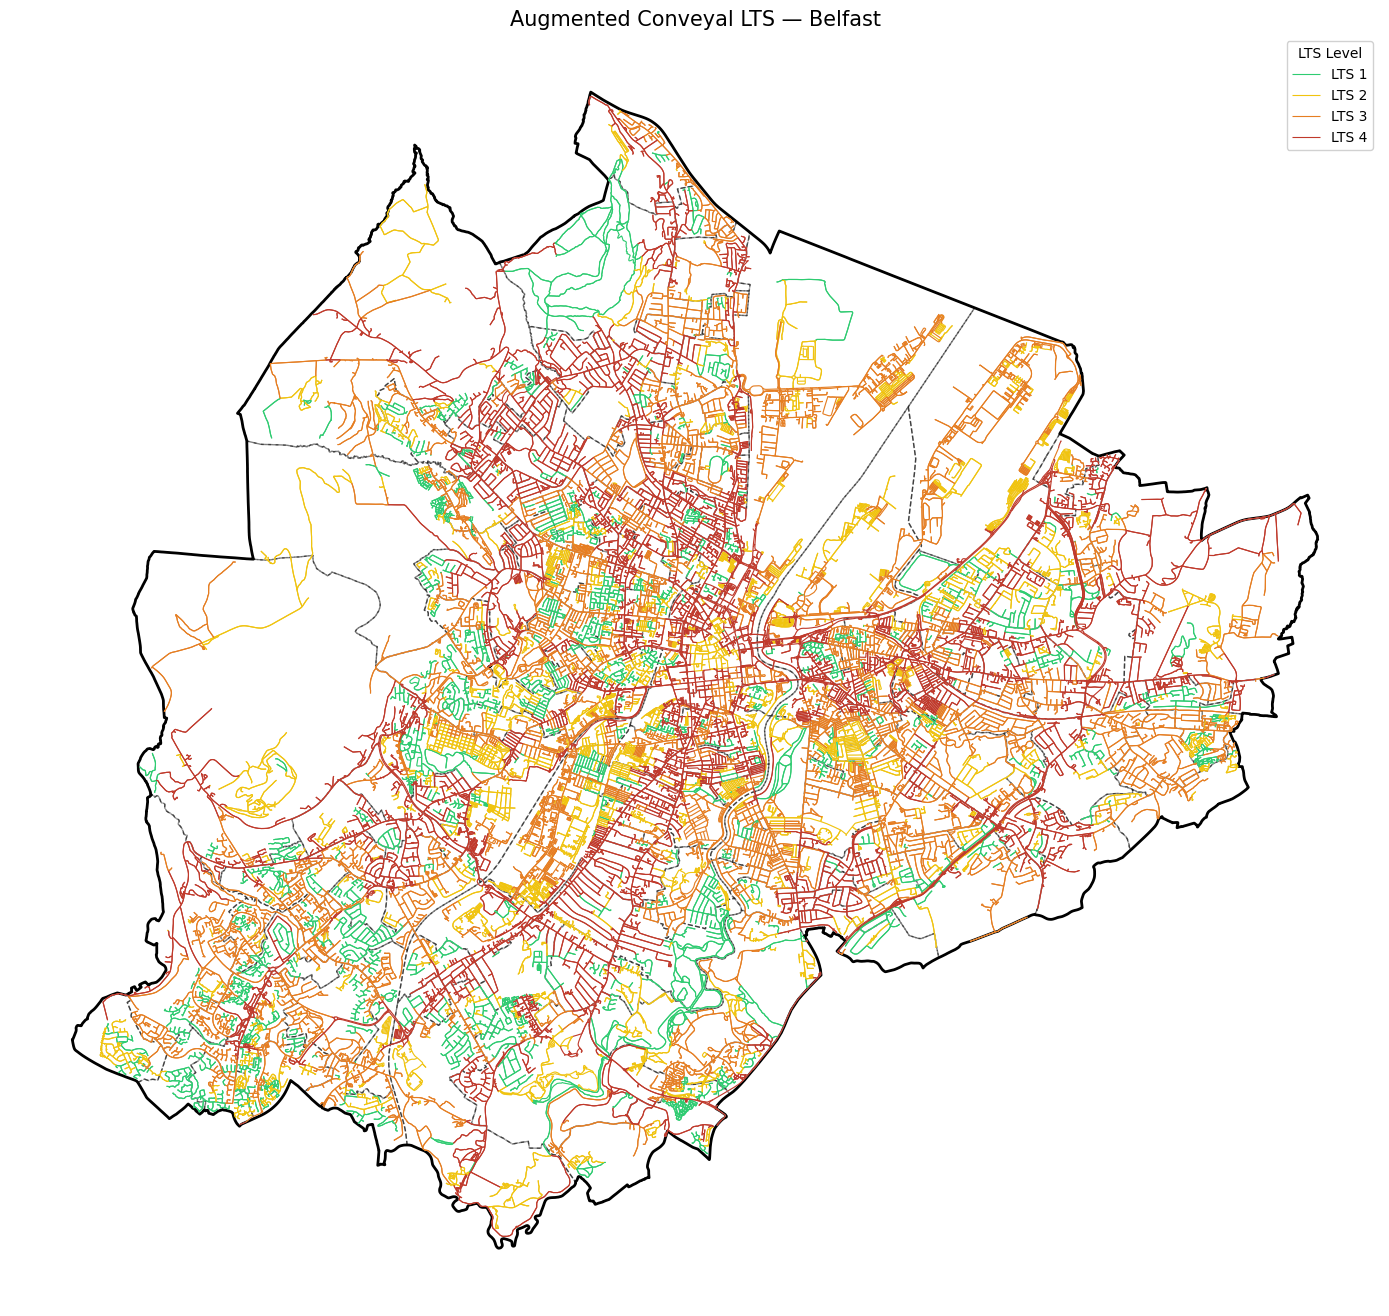

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(14, 14))

plot_gdf = edges

# Plot study area boundary
study_area.to_crs(edges.crs).plot(
    ax=ax, facecolor='none', edgecolor='black',
    linewidth=1, linestyle='--', alpha = 0.5, zorder=0, label='Study area boundary'
)

gpd.GeoDataFrame(geometry=[belfast_boundary], crs=study_area.crs).to_crs(edges.crs).plot(
    ax=ax, facecolor='none', edgecolor='black',
    linewidth=2, linestyle='-', alpha=1, zorder=0
)

# Base network
plot_gdf.plot(ax=ax, color='#eeeeee', linewidth=0.5, zorder=1)

# LTS layers
color_map = {
    'LTS 1': '#2ecc71',
    'LTS 2': '#f1c40f',
    'LTS 3': '#e67e22',
    'LTS 4': '#c0392b',
    'Missing (Service)': '#9b59b6',
}
for status, color in color_map.items():
    subset = plot_gdf[plot_gdf['lts_status'] == status]
    if not subset.empty:
        subset.plot(ax=ax, color=color, linewidth=0.8, label=status,
                    zorder=3 if 'Missing' in status else 2)

ax.set_title('Augmented Conveyal LTS — Belfast', fontsize=15)
ax.legend(title='LTS Level', loc='upper right', framealpha=0.9)
ax.axis('off')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'Belfast_LTS.png', dpi=500, bbox_inches='tight')
plt.show()


#### Interactive Map

In [ ]:
# 1. Prepare the data: Ensure CRS is WGS84 for web compatibility
map_gdf = plot_gdf.to_crs(epsg=4326)

# 2. Define the strict color mapping for LTS categories
color_dict = {
    'LTS 1': '#2ecc71',           # Green: Low stress
    'LTS 2': '#f1c40f',           # Yellow: Tolerate by most adults
    'LTS 3': '#e67e22',           # Orange: Enthusiastic but confident
    'LTS 4': '#c0392b',           # Red: High stress
    'Missing (Service)': '#9b59b6' # Purple: Unclassified/Service roads
}

# Get unique categories present in the data and map them to their colors
unique_categories = sorted(map_gdf['lts_status'].unique())
color_list = [color_dict.get(cat, '#cccccc') for cat in unique_categories]

# 3. Create the interactive exploration map
m = map_gdf.explore(
    column='lts_status',
    categories=unique_categories,
    cmap=color_list,
    tooltip=['name', 'lts_status'],
    popup=['name', 'lts_status', 'highway', 'surface'],
    tiles='CartoDB positron',
    style_kwds=dict(weight=0.6),
    legend_kwds=dict(caption='Level of Traffic Stress (LTS)'),
    name='Belfast LTS Network'
)

# 4. Add the Study Area Boundary as a reference layer
study_area_wgs84 = study_area.to_crs(epsg=4326)
folium.GeoJson(
    study_area_wgs84,
    name='Study Area Boundary',
    style_function=lambda x: {
        'fillColor': 'none',
        'color': 'black',
        'weight': 1,
        'dashArray': '5, 5'
    }
).add_to(m)

# 5. Final map adjustments
folium.LayerControl().add_to(m)
m.save(str(OUTPUT_DIR / 'Belfast_LTS_Interactive.html'))

# Display the map in your notebook
m
